WEB SCRAPING LIVE DATA FROM THE OFFICIAL NBA WEBSITE

In [13]:
!pip install nba_api pandas plotly seaborn matplotlib scikit-learn

LOAD THE DATASET

In [14]:
from nba_api.stats.endpoints import leaguedashplayerstats, leaguedashteamstats
import pandas as pd

# Get 2025-26 player stats
player_stats = leaguedashplayerstats.LeagueDashPlayerStats(season='2025-26')
players_df = player_stats.get_data_frames()[0]

# Get 2025-26 team stats
team_stats = leaguedashteamstats.LeagueDashTeamStats(season='2025-26')
teams_df = team_stats.get_data_frames()[0]

print(players_df.shape)
print(teams_df.shape)
players_df.head()

(582, 67)
(30, 54)


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1630639,A.J. Lawson,A.J.,1610612761,TOR,25.0,24,12,12,0.500,...,125,142,443,438,290,450,284,38,449,1
1,1631260,AJ Green,AJ,1610612749,MIL,26.0,78,31,47,0.397,...,271,540,229,126,496,175,284,38,139,1
2,1642358,AJ Johnson,AJ,1610612742,DAL,21.0,48,9,39,0.188,...,371,158,384,400,394,414,284,38,413,2
3,203932,Aaron Gordon,Aaron,1610612743,DEN,30.0,36,27,9,0.750,...,271,242,143,197,48,247,114,38,241,1
4,1628988,Aaron Holiday,Aaron,1610612745,HOU,29.0,57,38,19,0.667,...,179,274,323,321,99,354,284,38,348,1


DATA EXPLORATION AND CLEANING BEGINS

In [15]:
# Check what columns we have
print(players_df.columns.tolist())
print(teams_df.columns.tolist())

['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT']
['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_R

In [16]:
# Keep only the most useful player columns
players_clean = players_df[[
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'MIN',
    'PTS', 'REB', 'AST', 'STL', 'BLK', 'FG_PCT',
    'FG3_PCT', 'FT_PCT', 'TOV', 'PLUS_MINUS'
]].copy()

# Keep only players with meaningful minutes (at least 10 games, 15 min/game)
players_clean = players_clean[
    (players_clean['GP'] >= 10) &
    (players_clean['MIN'] >= 15)
]

print(f'Players remaining: {len(players_clean)}')

Players remaining: 506


In [17]:
# Clean team data
teams_clean = teams_df[[
    'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT',
    'PTS', 'REB', 'AST', 'STL', 'BLK',
    'FG_PCT', 'FG3_PCT', 'PLUS_MINUS'
]].copy()

print(teams_clean.head())

           TEAM_NAME  GP   W   L  W_PCT   PTS   REB   AST  STL  BLK  FG_PCT  \
0      Atlanta Hawks  82  46  36  0.561  9714  3570  2471  768  384   0.474   
1     Boston Celtics  82  56  26  0.683  9418  3802  2021  585  410   0.467   
2      Brooklyn Nets  82  20  62  0.244  8686  3225  2050  653  350   0.443   
3  Charlotte Hornets  82  44  38  0.537  9513  3778  2160  577  370   0.460   
4      Chicago Bulls  82  31  51  0.378  9537  3694  2335  627  410   0.469   

   FG3_PCT  PLUS_MINUS  
0    0.371       198.0  
1    0.367       631.0  
2    0.340      -819.0  
3    0.378       396.0  
4    0.356      -427.0  


PLAYER ANALYSIS

In [18]:
# Top 15 scorers
top_scorers = players_clean.nlargest(15, 'PTS')

import plotly.express as px

fig = px.bar(
    top_scorers, x='PTS', y='PLAYER_NAME',
    orientation='h',
    title='Top 15 Scorers — NBA 2025-26',
    labels={'PTS': 'Points Per Game', 'PLAYER_NAME': ''},
    color='PTS',
    color_continuous_scale='Greens'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

TRUE PPG COLUMN CREATION

In [19]:
players_clean['TRUE_PPG'] = round(players_clean['PTS'] / players_clean['GP'], 1)
players_clean['TRUE_RPG'] = round(players_clean['REB'] / players_clean['GP'], 1)
players_clean['TRUE_APG'] = round(players_clean['AST'] / players_clean['GP'], 1)
players_clean['TRUE_SPG'] = round(players_clean['STL'] / players_clean['GP'], 1)
players_clean['TRUE_BPG'] = round(players_clean['BLK'] / players_clean['GP'], 1)
players_clean['TRUE_TOV'] = round(players_clean['TOV'] / players_clean['GP'], 1)

print("Per game stats created successfully")
print(players_clean[['PLAYER_NAME', 'TRUE_PPG', 'TRUE_RPG', 'TRUE_APG']].head(3))

Per game stats created successfully
   PLAYER_NAME  TRUE_PPG  TRUE_RPG  TRUE_APG
0  A.J. Lawson       4.2       1.8       0.3
1     AJ Green      10.4       2.7       1.9
2   AJ Johnson       3.3       1.1       1.0


FILTERING MVP CANDIDATES BY OVERRALL PERFORMANCE (COMPOSITE SCORE)

In [20]:
mvp_candidates = players_clean[players_clean['GP'] >= 50].copy()

mvp_candidates['COMPOSITE_SCORE'] = (
    mvp_candidates['TRUE_PPG'] * 1.0 +
    mvp_candidates['TRUE_RPG'] * 1.2 +
    mvp_candidates['TRUE_APG'] * 1.5 +
    mvp_candidates['TRUE_SPG'] * 2.0 +
    mvp_candidates['TRUE_BPG'] * 2.0 -
    mvp_candidates['TRUE_TOV'] * 1.5
)

top_mvp = mvp_candidates.nlargest(10, 'COMPOSITE_SCORE')[
    ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP',
     'TRUE_PPG', 'TRUE_RPG', 'TRUE_APG', 'COMPOSITE_SCORE']
]
print(top_mvp)

                 PLAYER_NAME TEAM_ABBREVIATION  GP  TRUE_PPG  TRUE_RPG  \
429             Nikola Jokić               DEN  65      27.7      12.9   
372              Luka Dončić               LAL  64      33.5       7.7   
559        Victor Wembanyama               SAS  64      25.0      11.5   
501  Shai Gilgeous-Alexander               OKC  68      31.1       4.3   
554             Tyrese Maxey               PHI  70      28.3       4.1   
234            Jalen Johnson               ATL  72      22.5      10.3   
71           Cade Cunningham               DET  64      23.9       5.5   
320            Kawhi Leonard               LAC  65      27.9       6.4   
260             Jaylen Brown               BOS  71      28.7       6.9   
154         Donovan Mitchell               CLE  70      27.9       4.5   

     TRUE_APG  COMPOSITE_SCORE  
429      10.7            58.08  
372       8.3            53.39  
559       3.1            48.05  
501       6.6            47.26  
554       6.6       

TEAM ANALYSIS USING WIN PERCENTAGE

In [21]:
# Win percentage bar chart
fig3 = px.bar(
    teams_clean.sort_values('W_PCT', ascending=False),
    x='TEAM_NAME', y='W_PCT',
    title='NBA Team Win % — 2024-25 Season',
    labels={'W_PCT': 'Win %', 'TEAM_NAME': ''},
    color='W_PCT',
    color_continuous_scale='Greens'
)
fig3.update_layout(xaxis_tickangle=-45)
fig3.show()

OFFENCE VS DEFENCE - POINTS SCORED VS +/-

In [22]:
# Offence vs Defence — Points scored vs Plus/Minus
fig4 = px.scatter(
    teams_clean, x='PTS', y='PLUS_MINUS',
    hover_name='TEAM_NAME',
    title='Team Offence vs Overall Dominance',
    labels={'PTS': 'Points Per Game', 'PLUS_MINUS': 'Plus/Minus'},
    color='W_PCT',
    size='W',
    color_continuous_scale='RdYlGn'
)
fig4.show()

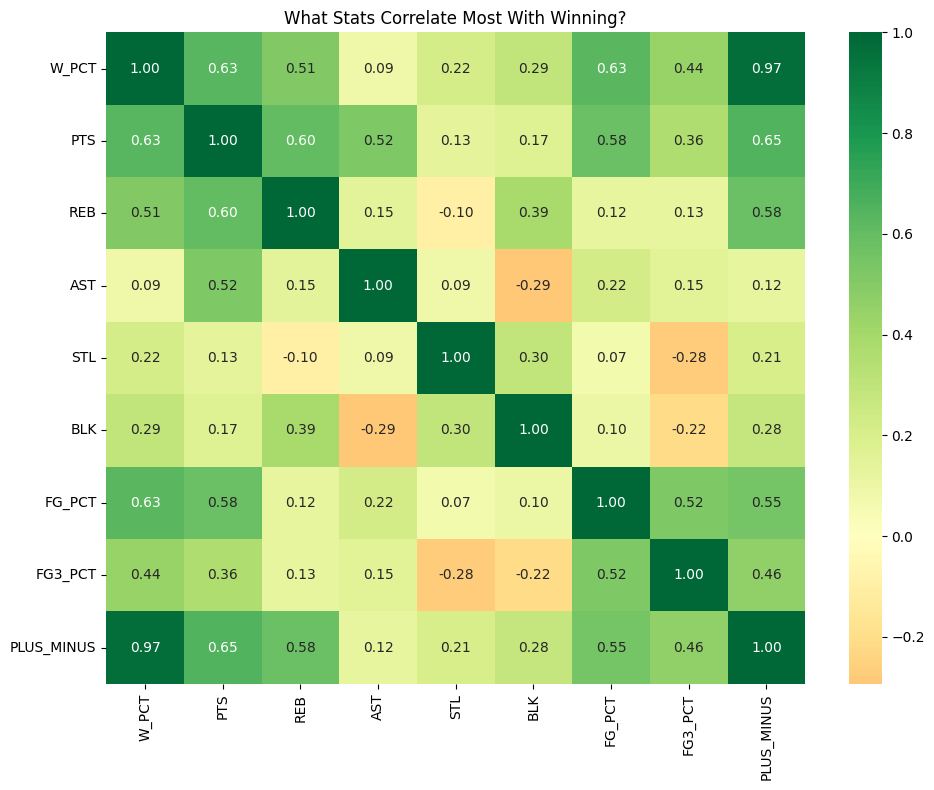

In [23]:
# Correlation heatmap — what stats relate to winning?
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = ['W_PCT', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'FG_PCT', 'FG3_PCT', 'PLUS_MINUS']
corr = teams_clean[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('What Stats Correlate Most With Winning?')
plt.tight_layout()
plt.show()

In [24]:
# Correlation of every stat with win percentage, ranked strongest to weakest
correlations = teams_clean[corr_cols].corr()['W_PCT'].drop('W_PCT')
correlations = correlations.abs().sort_values(ascending=False)
print(correlations)

PLUS_MINUS    0.972673
PTS           0.632059
FG_PCT        0.630078
REB           0.514901
FG3_PCT       0.443679
BLK           0.288581
STL           0.216831
AST           0.091639
Name: W_PCT, dtype: float64


RUNNING A COMPASRISON CHART FOR TOP FIVE MVP CANDIDATES

In [25]:
# Pull top 5 candidates
top5 = mvp_candidates.nlargest(5, 'COMPOSITE_SCORE')[
    ['PLAYER_NAME', 'TRUE_PPG', 'TRUE_RPG', 'TRUE_APG',
     'TRUE_SPG', 'TRUE_BPG', 'COMPOSITE_SCORE']
].reset_index(drop=True)

print(top5)

               PLAYER_NAME  TRUE_PPG  TRUE_RPG  TRUE_APG  TRUE_SPG  TRUE_BPG  \
0             Nikola Jokić      27.7      12.9      10.7       1.4       0.8   
1              Luka Dončić      33.5       7.7       8.3       1.6       0.5   
2        Victor Wembanyama      25.0      11.5       3.1       1.0       3.1   
3  Shai Gilgeous-Alexander      31.1       4.3       6.6       1.4       0.8   
4             Tyrese Maxey      28.3       4.1       6.6       1.9       0.8   

   COMPOSITE_SCORE  
0            58.08  
1            53.39  
2            48.05  
3            47.26  
4            44.92  


## NBA 2024-25 Performance Analysis — Conclusions

### Top Players
The leading scorer this season is LUKA DONCIC averaging 33.5 PPG.
The most well-rounded player by composite score and leader at the MVP ladder is NIKOLA JOKIC.


**THE JOKIC ARGUMENT**

The chart tells the story clearly. Jokic doesn't lead in any single category — Doncic scores more, Wembanyama blocks more — but he's the only player who dominates across rebounds AND assists simultaneously. No centre in NBA history has averaged a triple-double, and Jokic is right at that threshold with 27.7 / 12.9 / 10.7.
The composite score rewards that balance heavily, which is why he finishes 4.7 points clear of Doncic despite scoring 5.8 fewer points per game. In basketball terms, a player who does everything at an elite level is more valuable than a player who does one thing at a historic level. That's the Jokic argument in numbers.

### Team Insights
The best performing team by win % is OKLAHOMA CITY THUNDER at 0.78%.
The heatmap reveals that PLUS/MINUS has the strongest correlation
with winning. The stat most strongly correlated with winning this season was
Plus/Minus, suggesting that the best teams don't just score points
— they consistently outscore their opponents across every minute
on the court, regardless of who is playing. This points to roster
depth and team cohesion as key drivers of success in the 2024-25 season..

### Tools used
Python, nba_api, pandas, Plotly, seaborn, scikit-learn